In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# 1. Carga de una muestra si el archivo entero es muy pesado para la RAM inicial (opcional)
# df = pd.read_csv('../data/raw/steam_reviews.csv', nrows=500000) 
df = pd.read_csv('../data/raw/steam_reviews.csv', nrows=500000)

In [7]:
# 2. Información general y nulos
print("--- Info del Dataset ---")
print(df.info())

print("\n--- Porcentaje de Nulos ---")
print(df.isna().mean() * 100)

--- Info del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Unnamed: 0                      500000 non-null  int64  
 1   app_id                          500000 non-null  int64  
 2   app_name                        500000 non-null  str    
 3   review_id                       500000 non-null  int64  
 4   language                        500000 non-null  str    
 5   review                          499222 non-null  str    
 6   timestamp_created               500000 non-null  int64  
 7   timestamp_updated               500000 non-null  int64  
 8   recommended                     500000 non-null  bool   
 9   votes_helpful                   500000 non-null  int64  
 10  votes_funny                     500000 non-null  int64  
 11  weighted_vote_score             500000 non-null  float64
 12  co

In [8]:
df.head(10)

,Unnamed: 0,app_id,app_name,review_id,language,review,timestamp_created,timestamp_updated,recommended,votes_helpful,...,steam_purchase,received_for_free,written_during_early_access,author.steamid,author.num_games_owned,author.num_reviews,author.playtime_forever,author.playtime_last_two_weeks,author.playtime_at_review,author.last_played
0,0,292030,The Witcher 3: Wild Hunt,85185598,schinese,不玩此生遗憾，RPG游戏里的天花板，太吸引人了,1611381629,1611381629,True,0,...,True,False,False,76561199095369542,6,2,1909.0,1448.0,1909.0,1.611343e+09
1,1,292030,The Witcher 3: Wild Hunt,85185250,schinese,拔DIAO无情打桩机--杰洛特!!!,1611381030,1611381030,True,0,...,True,False,False,76561198949504115,30,10,2764.0,2743.0,2674.0,1.611386e+09
2,2,292030,The Witcher 3: Wild Hunt,85185111,schinese,巫师3NB,1611380800,1611380800,True,0,...,True,False,False,76561199090098988,5,1,1061.0,1061.0,1060.0,1.611384e+09
3,3,292030,The Witcher 3: Wild Hunt,85184605,english,"One of the best RPG's of all time, worthy of a...",1611379970,1611379970,True,0,...,True,False,False,76561199054755373,5,3,5587.0,3200.0,5524.0,1.611384e+09
4,4,292030,The Witcher 3: Wild Hunt,85184287,schinese,大作,1611379427,1611379427,True,0,...,True,False,False,76561199028326951,7,4,217.0,42.0,217.0,1.610788e+09
5,5,292030,The Witcher 3: Wild Hunt,85184171,english,"good story, good graphics. lots to do.",1611379264,1611379264,True,0,...,True,False,False,76561198170193529,11,1,823.0,823.0,823.0,1.611379e+09
6,6,292030,The Witcher 3: Wild Hunt,85184064,english,"dis gud,",1611379091,1611379091,True,0,...,True,False,False,76561198119302812,27,2,4192.0,3398.0,4192.0,1.611352e+09
7,7,292030,The Witcher 3: Wild Hunt,85183602,turkish,.\n,1611378312,1611378312,True,0,...,True,False,False,76561199084188849,9,1,2701.0,0.0,2701.0,1.609671e+09
8,8,292030,The Witcher 3: Wild Hunt,85183227,schinese,年度最佳的作品，没啥好夸的，神作,1611377703,1611377703,True,0,...,True,False,False,76561198130808993,581,17,6921.0,222.0,6921.0,1.611317e+09
9,9,292030,The Witcher 3: Wild Hunt,85182785,spanish,great game,1611377005,1611377005,True,0,...,True,False,False,76561198301724112,38,5,2399.0,333.0,2364.0,1.611379e+09


In [9]:
#Contar la cantidad de nulos en cada columna
print(df.isnull().sum())

Unnamed: 0                          0
app_id                              0
app_name                            0
review_id                           0
language                            0
review                            778
timestamp_created                   0
timestamp_updated                   0
recommended                         0
votes_helpful                       0
votes_funny                         0
weighted_vote_score                 0
comment_count                       0
steam_purchase                      0
received_for_free                   0
written_during_early_access         0
author.steamid                      0
author.num_games_owned              0
author.num_reviews                  0
author.playtime_forever             0
author.playtime_last_two_weeks      0
author.playtime_at_review         361
author.last_played                  0
dtype: int64


<Axes: title={'center': 'Distribución de Idiomas en las Reseñas'}, xlabel='language'>

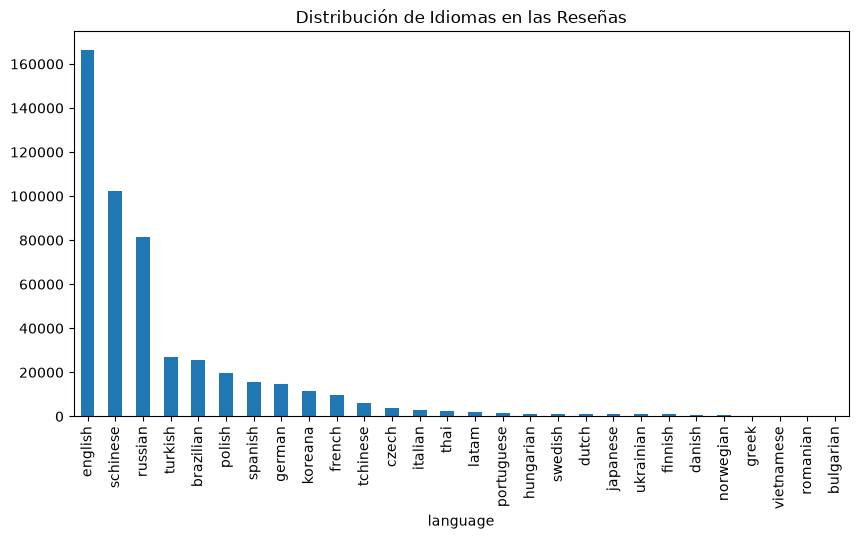

In [10]:
df['language'].value_counts().plot(kind='bar', figsize=(10, 5), title='Distribución de Idiomas en las Reseñas')

In [11]:
# 1. Filtrar solo inglés y eliminar filas donde la reseña sea nula 
df_en = df[(df['language'] == 'english') & (df['review'].notna())].copy()

# 2. Calcular cantidad de palabras usando métricas vectorizadas de Pandas
df_en['word_count'] = df_en['review'].str.split().str.len()

# 3. Ver porcentaje de reseñas cortas (<= 3 palabras)
print("Porcentaje de reseñas cortas (<= 3 palabras):", (df_en['word_count'] <= 3).mean() * 100)
print("Porcentaje de reseñas largas (> 5 palabras):", (df_en['word_count'] > 5).mean() * 100)

Porcentaje de reseñas cortas (<= 3 palabras): 25.210149767436263
Porcentaje de reseñas largas (> 5 palabras): 65.29715808918654


In [12]:
# 4. Calcular la mediana de horas jugadas en el subset de inglés
median_playtime = df_en['author.playtime_at_review'].median()

# 5. Imputar los valores nulos con esa mediana
df_en['author.playtime_at_review'] = df_en['author.playtime_at_review'].fillna(median_playtime)

# 6. Comprobación de que ya no quedan nulos
print(f"Mediana aplicada: {median_playtime} minutos")
print("Nulos restantes en playtime:", df_en['author.playtime_at_review'].isna().sum())

Mediana aplicada: 3759.0 minutos
Nulos restantes en playtime: 0


In [15]:
# Balance de clases: Proporción de reseñas positivas (True) vs negativas (False) en inglés
print("--- Balance de Clases (Aplicado sobre la columna 'recommended') ---")
print(df_en['recommended'].value_counts(normalize=True) * 100)

--- Balance de Clases (Aplicado sobre la columna 'recommended') ---
recommended
True     97.543188
False     2.456812
Name: proportion, dtype: float64


In [16]:
# Convertir timestamp UNIX a fecha y ver rango temporal
df_en['date'] = pd.to_datetime(df_en['timestamp_created'], unit='s')
print("\n--- Rango Temporal ---")
print(f"Desde: {df_en['date'].min()} hasta: {df_en['date'].max()}")


--- Rango Temporal ---
Desde: 2015-05-18 23:09:39 hasta: 2021-01-23 05:32:50


In [21]:
# Guardar el subset limpio en la carpeta de datos procesados
# Usamos index=False para no guardar la columna de índices de Pandas
df_en.to_csv('../data/processed/reviews_en_clean.csv', index=False)

## Resumen de decisiones de la fase 1: EDA y tratamiento de datos

### 1. Por que dejar solo las reseñas en ingles?
* **Justificación:** El análisis de la muestra reveló que el inglés es el idioma claramente predominante (~32% del dataset, equivalente a miles de filas utilizables).
* **Beneficio técnico:** Elimina problemas de tokenización por caracteres no latinos (ej. chino, cirílico) en clasificadores monolingües, garantizando un vocabulario limpio y denso para las fases siguientes sin comprometer la representación estadística del dataset.

### 2. Tratamiento de valores nulos
* **Columna `review` (778 nulos):** Se optó por **eliminar** las filas. Rellenar o imputar texto de reseñas introduce ruido y sesgo semántico artificial que perjudica el entrenamiento en NLP. Perder <0.15% de los datos no afecta la muestra.
* **Columna `author.playtime_at_review` (361 nulos):** Se optó por **imputar con la mediana** (debido al sesgo de cola larga por valores extremos de horas jugadas) o eliminar de cara al análisis de calidad.

### 3. Análisis de longitud y ruido (`word_count`)
* **Hallazgo:** El **25.21%** de las reseñas en inglés tienen **3 palabras o menos** (ej. *"10/10"*, *"good game"*).
* **Impacto:** Aunque aportan señal simple para el modelo baseline binario (Fase 2), no contienen contexto suficiente para la clasificación multi-etiqueta por aspectos (Fase 3). Se evaluará un filtro de longitud mínima antes de entrenar el modelo de Deep Learning.

### 4. Balance de Clases (`recommended`) y Rango Temporal

* **Balance de Clases (Target):**
  * `True` (Recomendado / Positivo): **97.54%**
  * `False` (No recomendado / Negativo): **2.46%**
* **Conclusión & Estrategia:** Existe un **desbalance severo de clases**. 
  * Un modelo iluso (*naive*) que clasifique todo como positivo obtendría 97.5% de *Accuracy* sin aprender nada.
  * **Acción para Fase 2:** Se descarta el *Accuracy* como métrica de evaluacion principal y se adoptan **F1-Score / Macro-F1**. Se aplicarán técnicas de ponderación de clases (`class_weight='balanced'`) o submuestreo (*undersampling*) de la clase positiva al armar los conjuntos de entrenamiento.

* **Rango Temporal:**
  * **Desde:** May 2015 — **Hasta:** Ene 2021 (~5.5 años de datos).
* **Conclusión:** El rango temporal es continuo y libre de sesgos de fragmentación, ideal para la construcción de series temporales de volumen de quejas en la **Fase 4 (Detección de Review Bombing)**.